# Project 2 — Demand Forecasting / Time Series Modeling

Using the same Online Retail II dataset to forecast daily sales demand.
Built a Prophet model to predict next 30 days of revenue.

The Railofy connection: at my internship I managed dispatch planning manually
across 65 stations. A forecasting model like this would have predicted peak
demand days automatically and reduced our undelivery rate even further.

Approach: Daily aggregation → trend/seasonality visualization → Prophet forecast → MAE/RMSE evaluation

In [5]:
# starting with imports - took me a bit to figure out
# prophet wasnt in anaconda by default, had to pip install it separately
# sklearn.metrics is for checking how accurate the forecast is at the end

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries loaded!")

Libraries loaded!


In [6]:
# reusing the same dataset from project 1 so no extra download needed
# copy pasted the cleaning steps from project 1 since the data is the same

df = pd.read_csv("D:\\Data_Science\\Projects\\Project 1\\Dataset\\archive\\online_retail_II.csv", encoding='latin-1')

df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

df['TotalAmount'] = df['Quantity'] * df['Price']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# prophet requires exactly two columns - ds for date and y for the value
# spent some time figuring this out from the prophet docs
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalAmount'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print("Daily sales table created!")
print("Total days in dataset:", len(daily_sales))
daily_sales.head(10)

Daily sales table created!
Total days in dataset: 604


,ds,y
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05
5,2009-12-06,24580.72
6,2009-12-07,33169.63
7,2009-12-08,44804.34
8,2009-12-09,31113.60
9,2009-12-10,38806.36


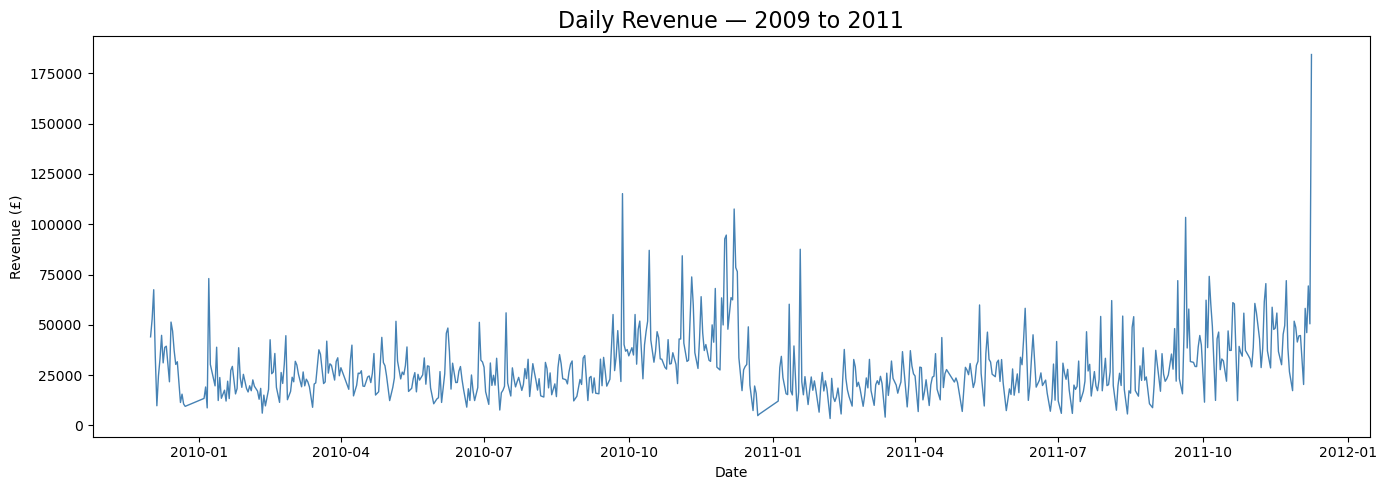

Max revenue day: 2011-12-09 00:00:00
Max revenue amount: £ 184367.28
Average daily revenue: £ 29376.54


In [7]:
# first thing i always do is plot the raw data before touching any model
# need to see if there are trends, spikes, weekends dips etc.

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['ds'], daily_sales['y'], color='steelblue', linewidth=1)
plt.title('Daily Revenue — 2009 to 2011', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

# checking peak day - curious to see when the highest sales happened
print("Max revenue day:", daily_sales.loc[daily_sales['y'].idxmax(), 'ds'])
print("Max revenue amount: £", round(daily_sales['y'].max(), 2))
print("Average daily revenue: £", round(daily_sales['y'].mean(), 2))

In [8]:
# splitting data into train and test
# using last 30 days as test set to check how accurate the model is
# everything before that is training data

train = daily_sales[:-30]
test = daily_sales[-30:]

print("Training data size:", len(train), "days")
print("Test data size:", len(test), "days")
print("Training period:", train['ds'].min(), "to", train['ds'].max())
print("Testing period:", test['ds'].min(), "to", test['ds'].max())

# fitting the prophet model - this is literally just 2 lines
# prophet automatically detects weekly and yearly seasonality
model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
model.fit(train)

print("\nModel trained successfully!")

Training data size: 574 days
Test data size: 30 days
Training period: 2009-12-01 00:00:00 to 2011-11-04 00:00:00
Testing period: 2011-11-06 00:00:00 to 2011-12-09 00:00:00


17:41:15 - cmdstanpy - INFO - Chain [1] start processing
17:41:16 - cmdstanpy - INFO - Chain [1] done processing



Model trained successfully!


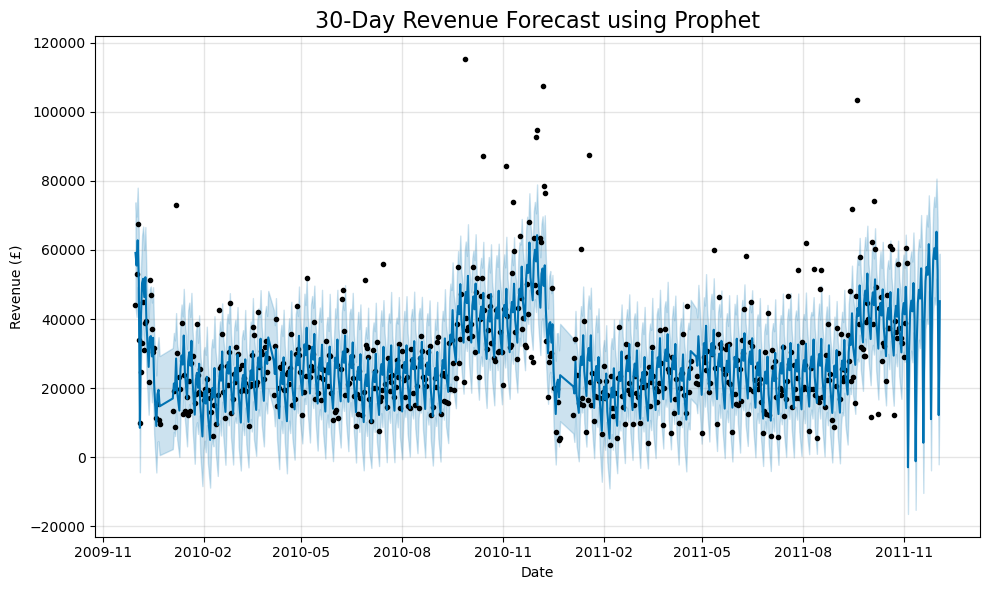

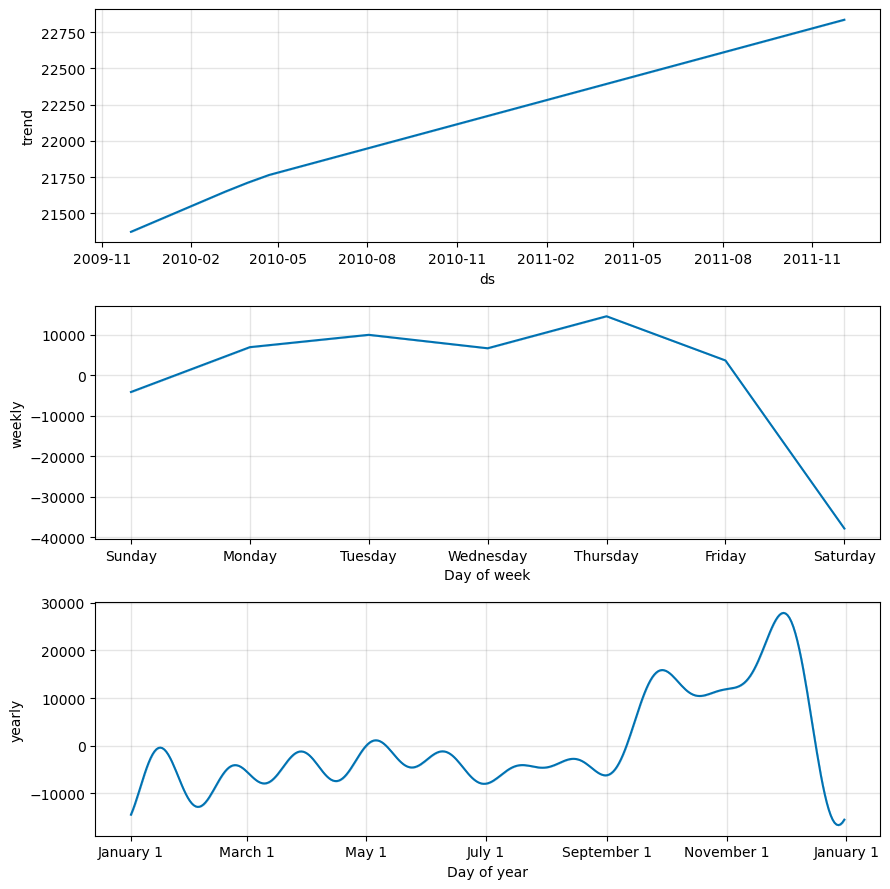

In [9]:
# making future dates for prophet to predict on
# 30 periods = next 30 days after our training data ends

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# plotting the forecast
# blue line = actual data, blue shaded area = uncertainty range
fig = model.plot(forecast)
plt.title('30-Day Revenue Forecast using Prophet', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

# this shows the trend and seasonality components separately
# really useful to understand what prophet actually learned
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

Model Accuracy on last 30 days:
MAE  (Mean Absolute Error): £12336.36
RMSE (Root Mean Sq Error):  £14762.63
Average actual revenue:     £43472.09
Average predicted revenue:  £48744.08


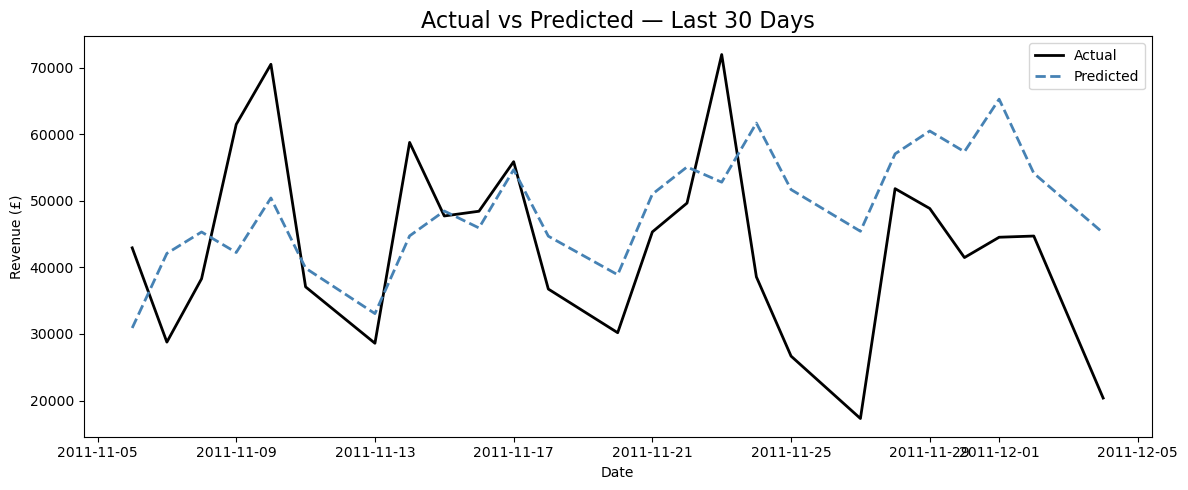

In [10]:
# checking how accurate the model was on the 30 days it never saw
# merging forecast with actual test values to compare

forecast_test = forecast[['ds', 'yhat']].tail(30)
comparison = test.merge(forecast_test, on='ds', how='inner')

# MAE = on average how many pounds off was our prediction
# RMSE = similar but punishes bigger mistakes more heavily
mae = mean_absolute_error(comparison['y'], comparison['yhat'])
rmse = np.sqrt(mean_squared_error(comparison['y'], comparison['yhat']))

print("Model Accuracy on last 30 days:")
print(f"MAE  (Mean Absolute Error): £{round(mae, 2)}")
print(f"RMSE (Root Mean Sq Error):  £{round(rmse, 2)}")
print(f"Average actual revenue:     £{round(comparison['y'].mean(), 2)}")
print(f"Average predicted revenue:  £{round(comparison['yhat'].mean(), 2)}")

# plotting actual vs predicted for the test period
plt.figure(figsize=(12, 5))
plt.plot(comparison['ds'], comparison['y'], label='Actual', color='black', linewidth=2)
plt.plot(comparison['ds'], comparison['yhat'], label='Predicted', color='steelblue', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted — Last 30 Days', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# wrapping up with business insights from what the model found
# this is the part that matters most in a real job

print("=" * 60)
print("PROJECT 2 - DEMAND FORECASTING RESULTS")
print("=" * 60)

print(f"""
MODEL PERFORMANCE:
- MAE:  £12,336  (avg daily error)
- RMSE: £14,762
- Avg actual revenue: £43,472/day

KEY FINDINGS FROM PROPHET:

1. TREND
   - Revenue grew steadily from ~£21,500/day in 2009
     to ~£22,800/day baseline by end of 2011
   - Business is healthy and growing

2. WEEKLY PATTERN
   - Thursday is peak revenue day (+£13,000 above baseline)
   - Saturday is lowest (-£40,000 below baseline)
   - This is a B2B retailer - weekends are dead

3. YEARLY PATTERN  
   - November is the biggest month every year
   - January always dips after Christmas rush
   - Sep-Nov = ramp up period for holiday season

RAILOFY CONNECTION:
   - At my internship I did dispatch planning manually
   - A model like this would predict which station days
     need more inventory stocked in advance
   - Could have reduced our undelivery rate below 0.5%
""")

# saving forecast results
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30).to_csv(
    "D:\\Data_Science\\Projects\\Project 2\\forecast_results.csv", index=False
)
print("Forecast saved!")
print("PROJECT 2 COMPLETE!")

PROJECT 2 - DEMAND FORECASTING RESULTS

MODEL PERFORMANCE:
- MAE:  £12,336  (avg daily error)
- RMSE: £14,762
- Avg actual revenue: £43,472/day

KEY FINDINGS FROM PROPHET:

1. TREND
   - Revenue grew steadily from ~£21,500/day in 2009
     to ~£22,800/day baseline by end of 2011
   - Business is healthy and growing

2. WEEKLY PATTERN
   - Thursday is peak revenue day (+£13,000 above baseline)
   - Saturday is lowest (-£40,000 below baseline)
   - This is a B2B retailer - weekends are dead

3. YEARLY PATTERN  
   - November is the biggest month every year
   - January always dips after Christmas rush
   - Sep-Nov = ramp up period for holiday season

RAILOFY CONNECTION:
   - At my internship I did dispatch planning manually
   - A model like this would predict which station days
     need more inventory stocked in advance
   - Could have reduced our undelivery rate below 0.5%

Forecast saved!
PROJECT 2 COMPLETE!
